In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np

# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [11]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


Total images found: 8438
Training set size: 6750
Test set size: 1688

Data pipelines created successfully.
Image batch shape: (64, 200, 200, 1)
Labels batch shape: (64,)


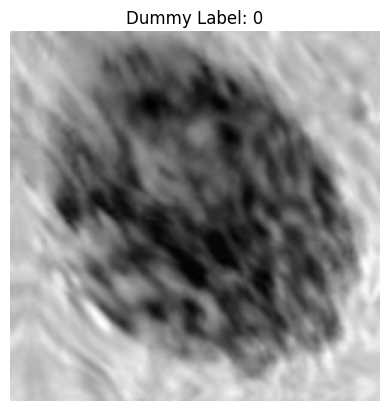

In [12]:
import tensorflow as tf
import os
import glob
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. Configuration ---
IMAGES_UNLABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/d"
IMAGES_LABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/test_v2"
INPUT_SHAPE = (200, 200) # Use a tuple for image size
BATCH_SIZE = 64

# --- 2. Data Loading and Preprocessing Functions ---
def load_and_preprocess_image(path):
    """Loads and preprocesses a single image."""
    image = tf.io.read_file(path)
    # Decode as grayscale, matching the model's expected input channels
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [INPUT_SHAPE[0], INPUT_SHAPE[1]])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_dataset(file_list, batch_size):
    """Creates a tf.data.Dataset from a list of file paths."""
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    # --- THIS IS THE KEY CHANGE ---
    # Add a dummy label of 0 to each image to create the (image, label) tuple
    ds = ds.map(lambda image: (image, 0))
    
    ds = ds.shuffle(buffer_size=1000) # Shuffle the data
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# --- 3. Prepare File Lists ---
# Get all image paths
unlabeled_files = glob.glob(os.path.join(IMAGES_UNLABELED_PATH, '*'))
labeled_files = glob.glob(os.path.join(IMAGES_LABELED_PATH, '*/*'))

# Combine them into a single list
all_files = unlabeled_files + labeled_files
print(f"Total images found: {len(all_files)}")

# Split the combined list for training and validation
train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_files)}")
print(f"Test set size: {len(test_files)}")

# --- 4. Create the Final Datasets ---
train_dataset = make_dataset(train_files, BATCH_SIZE)
test_dataset = make_dataset(test_files, BATCH_SIZE)

print("\nData pipelines created successfully.")

# --- 5. Verify the Data ---
for images, labels in train_dataset.take(1):
    print(f"Image batch shape: {images.shape}") # Should be (BATCH_SIZE, 200, 200, 1)
    print(f"Labels batch shape: {labels.shape}") # Should be (BATCH_SIZE,)
    plt.imshow(images[0].numpy().squeeze(), cmap='gray')
    plt.title(f'Dummy Label: {labels[0].numpy()}')
    plt.axis('off')
    plt.show()
    break

In [13]:
from tensorflow.keras import layers, Model

# --- Dynamic Hyperparameters ---
# We get the image shape directly from the data we loaded in Step 1
image_shape = (200, 200, 1)
latent_dim_a = 64
latent_dim_z = 128


# =============================================================
# Encoder 1: Auxiliary Inference Model q(a|x) - Class Version
# =============================================================
class Encoder_q_a_x(Model):
    """Maps an input image x to the parameters of the distribution for a."""
    def __init__(self, latent_dim, name='q_a_x_encoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # Define the layers of the network

        #200x200 -> 100x100
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW

        #100x100 -> 50x50
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW



        #50x50 -> 25x25
        self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        #25x25 -> 13x13
        self.conv4 = layers.Conv2D(256, 3, strides=1, padding='same')
        self.bn4 = layers.BatchNormalization() # NEW

        self.flatten = layers.Flatten()
        self.dense = layers.Dense(256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)
        self.mu_a_layer = layers.Dense(latent_dim, name='mu_a')
        self.log_var_a_layer = layers.Dense(latent_dim, name='log_var_a')

    def call(self, x):
        # Define the forward pass

        h = self.bn1(self.conv1(x))
        h = self.leaky_relu(h)
        h = self.bn2(self.conv2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.conv3(h))
        h = self.leaky_relu(h)
        h = self.bn4(self.conv4(h))
        h = self.leaky_relu(h)
        h = self.flatten(h)
        h = self.bn_dense(self.dense(h))
        h = self.leaky_relu(h)
        mu_a = self.mu_a_layer(h)
        log_var_a = self.log_var_a_layer(h)
        return mu_a, log_var_a

# =============================================================
# Encoder 2: Latent Inference Model q(z|x, a) - Class Version
# =============================================================
class Encoder_q_z_xa(Model):
    """Maps an image x AND an auxiliary 'a' to the parameters for z."""
    def __init__(self, latent_dim, name='q_z_xa_encoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # Define layers for processing the image 'x'
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW
        self.conv4 = layers.Conv2D(256, 3, strides=1, padding='same')
        self.bn4 = layers.BatchNormalization() # NEW

        self.flatten = layers.Flatten()
        # Define layers for the combined path
        self.dense1 = layers.Dense(256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)  

        self.mu_z_layer = layers.Dense(latent_dim, name='mu_z')
        self.log_var_z_layer = layers.Dense(latent_dim, name='log_var_z')

    def call(self, inputs):
        # The 'inputs' will be a list: [image_x, variable_a]
        x, a = inputs
        # Process 'x' through its layers
        h_x = self.bn1(self.conv1(x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn2(self.conv2(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn3(self.conv3(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn4(self.conv4(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.flatten(h_x)        
        # Concatenate the processed image features with the input 'a'
        h_concat = layers.concatenate([h_x, a])
        # Run the combined features through the final layers
        h = self.bn_dense(self.dense1(h_concat))
        h = self.leaky_relu(h)
        mu_z = self.mu_z_layer(h)
        log_var_z = self.log_var_z_layer(h)
        return mu_z, log_var_z

# --- Instantiate and Build the Encoders ---
q_a_x_model = Encoder_q_a_x(latent_dim=latent_dim_a)
q_z_xa_model = Encoder_q_z_xa(latent_dim=latent_dim_z)

# To print the summary, we need to "build" the models by passing a sample input.
# This lets Keras know the input shape and connect all the layers.
dummy_x = tf.zeros((BATCH_SIZE, *image_shape))
dummy_a = tf.zeros((BATCH_SIZE, latent_dim_a))

# Calling the models on dummy data to build them
_ = q_a_x_model(dummy_x)
_ = q_z_xa_model([dummy_x, dummy_a])

print("--- Encoder q(a|x) Summary ---")
q_a_x_model.summary()

print("\n--- Encoder q(z|x, a) Summary ---")
q_z_xa_model.summary()

--- Encoder q(a|x) Summary ---


Model: "q_a_x_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (64, 100, 100, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (64, 100, 100, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (64, 50, 50, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (64, 50, 50, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (64, 50, 50, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (64, 50, 50, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (64, 50, 50, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (64, 50, 50, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (64, 640000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (64, 256)              │   163,840,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_a (Dense)                    │ (64, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_a (Dense)               │ (64, 64)               │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,263,936 (626.62 MB)

 Trainable params: 164,262,464 (626.61 MB)

...

Model: "q_z_xa_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (64, 100, 100, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (64, 100, 100, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (64, 50, 50, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (64, 50, 50, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (64, 50, 50, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (64, 50, 50, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (64, 50, 50, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (64, 50, 50, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (64, 640000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (64, 256)              │   163,856,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_z (Dense)                    │ (64, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_z (Dense)               │ (64, 128)              │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,313,216 (626.81 MB)

 Trainable params: 164,311,744 (626.80 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [14]:
from tensorflow.keras import layers, Model

# =============================================================
# Decoder 1: Main Generative Model p(x|z) - Class Version
# =============================================================
class Decoder_p_x_z(Model):
    """Generates an image x from a latent variable z."""
    def __init__(self, image_shape, name='p_x_z_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # We start by projecting and reshaping the latent z
        # The target shape is the shape of the output of the last conv layer in the encoder
        self.dense = layers.Dense(13 * 13 * 256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.reshape = layers.Reshape((13, 13, 256))

        # Then we use transposed convolutions to upsample back to the image shape
        #13x13 -> 26x26
        self.conv_transpose1 = layers.Conv2DTranspose(256, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW

        #26x26 -> 52x52
        self.conv_transpose2 = layers.Conv2DTranspose(128, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW

        #52x52 -> 104x104
        self.conv_transpose3 = layers.Conv2DTranspose(64, 5, strides=2, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        #104x104 -> 208x208
        self.conv_transpose4 = layers.Conv2DTranspose(32, 5, strides=2, padding='same')
        self.bn4 = layers.BatchNormalization() # NEW

        self.cropping = layers.Cropping2D(((4,4),(4,4)))
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)

        # It has 1 filter (for grayscale) and a sigmoid activation for pixel values [0, 1]
        self.conv_transpose_out = layers.Conv2DTranspose(image_shape[-1], 3, strides=1, padding='same', activation='sigmoid')


    def call(self, z):
        h = self.bn_dense(self.dense(z))
        h = self.leaky_relu(h)
        h = self.reshape(h)
        h = self.bn1(self.conv_transpose1(h))
        h = self.leaky_relu(h)
        h = self.bn2(self.conv_transpose2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.conv_transpose3(h))
        h = self.leaky_relu(h)
        h = self.bn4(self.conv_transpose4(h))
        h = self.leaky_relu(h)
        h = self.cropping(h)
        x_reconstructed = self.conv_transpose_out(h)
        return x_reconstructed
# =============================================================
# Decoder 2: Auxiliary Generative Model p(a|z,x) - Class Version
# =============================================================
class Decoder_p_a_zx(Model):
    """Predicts parameters for 'a' from a latent 'z' and an image 'x'."""
    def __init__(self, latent_dim, name='p_a_zx_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256)
        self.bn1 = layers.BatchNormalization() # NEW
        self.dense2 = layers.Dense(256)
        self.bn2 = layers.BatchNormalization() # NEW
        self.dense3 = layers.Dense(256)
        self.bn3 = layers.BatchNormalization() # NEW
        self.dense4 = layers.Dense(256)
        self.bn4 = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2) # NEW ACTIVATION

        # This decoder also outputs a distribution's parameters
        self.mu_a_pred_layer = layers.Dense(latent_dim, name='mu_a_pred')
        self.log_var_a_pred_layer = layers.Dense(latent_dim, name='log_var_a_pred')

    def call(self, inputs):
        z, x = inputs

        # We flatten the image x to combine it with z
        x_flat = self.flatten(x)

        # Concatenate and pass through dense layers
        h_concat = layers.concatenate([z, x_flat])

        h = self.bn1(self.dense1(h_concat))
        h = self.leaky_relu(h)
        h = self.bn2(self.dense2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.dense3(h))
        h = self.leaky_relu(h)
        h = self.bn4(self.dense4(h))
        h = self.leaky_relu(h)
        mu_a_pred = self.mu_a_pred_layer(h)
        log_var_a_pred = self.log_var_a_pred_layer(h)
        return mu_a_pred, log_var_a_pred

# --- Instantiate and Build the Decoders ---
p_x_z_model = Decoder_p_x_z(image_shape)
p_a_zx_model = Decoder_p_a_zx(latent_dim=latent_dim_a)

# Build the models by passing sample inputs
dummy_z = tf.zeros((BATCH_SIZE, latent_dim_z))
# The dummy_x for the p_a_zx_model is the original image, not flattened yet
dummy_x = tf.zeros((BATCH_SIZE, *image_shape))

_ = p_x_z_model(dummy_z)
_ = p_a_zx_model([dummy_z, dummy_x])

print("--- Decoder p(x|z) Summary ---")
p_x_z_model.summary()

print("\n--- Decoder p(a|z,x) Summary ---")
p_a_zx_model.summary()

--- Decoder p(x|z) Summary ---


Model: "p_x_z_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (64, 43264)            │     5,581,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (64, 43264)            │       173,056 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (64, 13, 13, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (64, 26, 26, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (64, 26, 26, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (64, 52, 52, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (64, 52, 52, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (64, 104, 104, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (64, 104, 104, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (64, 208, 208, 32)     │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (64, 208, 208, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_3 (Cropping2D)       │ (64, 200, 200, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (64, 200, 200, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,897,537 (26.31 MB)

 Trainable params: 6,810,049 (25.98 MB)

...

Model: "p_a_zx_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (64, 40000)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (64, 256)              │    10,273,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (64, 256)              │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (64, 256)              │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (64, 256)              │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (64, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_a_pred (Dense)               │ (64, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_a_pred (Dense)          │ (64, 64)               │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,507,392 (40.08 MB)

 Trainable params: 10,505,344 (40.07 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [15]:
from tensorflow.keras import layers, Model

# =============================================================
# Reparameterization Trick as a Layer
# =============================================================
class Sampling(layers.Layer):
    """
    Uses (mu, log_var) to sample z, the latent vector.
    This is the reparameterization trick.
    """
    def call(self, inputs):
        mu, log_var = inputs
        batch = tf.shape(mu)[0]
        dim = tf.shape(mu)[1]
        # Sample random noise from a standard normal distribution
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Compute the sample z = mu + sigma * epsilon
        # Note: sigma = exp(0.5 * log_var)
        return mu + tf.exp(0.5 * log_var) * epsilon

### The Loss Function

In [ ]:
class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim

def adgm_loss_fn(y_true, y_pred):
    """
    Calculates the ADGM loss as the negative of the Evidence Lower Bound (ELBO).
    """
    # 1. Reconstruction loss for the image x (log p(x|z))
    # We use binary cross-entropy, which is equivalent to the log-probability
    # for a Bernoulli distribution over the pixels.
    # recon_loss_x = tf.reduce_mean(tf.reduce_sum(
    #     tf.keras.losses.binary_crossentropy(y_true, y_pred['x_reconstructed']),
    #     axis=[1, 2]
    # ))
    custom_recon_loss = CustomLoss(y=0.17, z=0.83)
    recon_loss_x = custom_recon_loss(y_true, y_pred['x_reconstructed'])
    recon_loss_x = recon_loss_x * (200 * 200)



    # 2. KL divergence for z (KL[q(z|x,a) || p(z)])
    # This measures how much q(z|x,a) deviates from a standard normal distribution.
    kl_loss_z = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_z'] - tf.square(y_pred['mu_z']) - tf.exp(y_pred['log_var_z']),
        axis=1
    ))

    # 3. KL divergence for a (KL[q(a|x) || p(a)])
    # This measures how much q(a|x) deviates from a standard normal distribution.
    kl_loss_a = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_a'] - tf.square(y_pred['mu_a']) - tf.exp(y_pred['log_var_a']),
        axis=1
    ))
    
    # 4. Reconstruction loss for a (-log p(a|z,x))
    # This is the negative log-probability of the sampled 'a' under the
    # distribution predicted by the auxiliary decoder.
    log_p_a_zx = -0.5 * tf.reduce_sum(
        tf.square(y_pred['a_sampled'] - y_pred['mu_a_pred']) / tf.exp(y_pred['log_var_a_pred']) + \
        y_pred['log_var_a_pred'] + tf.math.log(2. * np.pi),
        axis=1
    )

    recon_loss_a = tf.reduce_mean(-log_p_a_zx)
    
    total_loss = recon_loss_x + recon_loss_a + 32 * kl_loss_z + 8 * kl_loss_a
   
    return {
        "loss": total_loss,
        "recon_loss_x": recon_loss_x,
        "recon_loss_a": recon_loss_a,
        "kl_loss_z": kl_loss_z,
        "kl_loss_a": kl_loss_a,
    }

### The model

In [17]:
from tensorflow.keras import layers, Model

# =============================================================
# The Full ADGM Model
# =============================================================
class ADGM(Model):
    """
    The complete Auxiliary Deep Generative Model.
    This class orchestrates the encoders, sampling, and decoders.
    """
    def __init__(self, image_shape, latent_dim_a, latent_dim_z, name='ADGM', **kwargs):
        super().__init__(name=name, **kwargs)
        # Instantiate all the component models
        self.q_a_x_model = Encoder_q_a_x(latent_dim=latent_dim_a)
        self.q_z_xa_model = Encoder_q_z_xa(latent_dim=latent_dim_z)
        self.p_x_z_model = Decoder_p_x_z(image_shape=image_shape)
        self.p_a_zx_model = Decoder_p_a_zx(latent_dim=latent_dim_a)
        self.sampling_layer = Sampling()

    def call(self, x):
        # === INFERENCE (Recognition) PATH ===
        # q(a|x) -> sample a
        mu_a, log_var_a = self.q_a_x_model(x)
        a = self.sampling_layer([mu_a, log_var_a])

        # q(z|x, a) -> sample z
        mu_z, log_var_z = self.q_z_xa_model([x, a])
        z = self.sampling_layer([mu_z, log_var_z])

        # === GENERATIVE PATH ===
        # p(x|z) -> reconstruct x
        x_reconstructed = self.p_x_z_model(z)

        # p(a|z, x) -> predict a's parameters
        mu_a_pred, log_var_a_pred = self.p_a_zx_model([z, x])
        
        # Return everything needed for the loss function
        return {
            "mu_a": mu_a, "log_var_a": log_var_a,
            "mu_z": mu_z, "log_var_z": log_var_z,
            "x_reconstructed": x_reconstructed,
            "mu_a_pred": mu_a_pred, "log_var_a_pred": log_var_a_pred,
            "a_sampled": a 
        }
    
    def train_step(self, data):
        images, _ = data
        
        with tf.GradientTape() as tape:
            model_outputs = self(images, training=True)
            # The loss function now returns a dictionary of metrics
            losses = adgm_loss_fn(images, model_outputs)
            total_loss = losses["loss"] # The main loss to optimize
            
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        # Return the dictionary of losses for Keras to track and display
        return losses

# --- Instantiate the Full Model ---
adgm_model = ADGM(image_shape, latent_dim_a, latent_dim_z)

# Test it on one batch of data to see the output structure
for images, _ in train_dataset.take(1):
    outputs = adgm_model(images)
    print("--- Full ADGM Model instantiated ---")
    print("Model outputs:")
    for key, value in outputs.items():
        print(f"  - {key}: shape {value.shape}")

--- Full ADGM Model instantiated ---
Model outputs:
  - mu_a: shape (64, 64)
  - log_var_a: shape (64, 64)
  - mu_z: shape (64, 128)
  - log_var_z: shape (64, 128)
  - x_reconstructed: shape (64, 200, 200, 1)
  - mu_a_pred: shape (64, 64)
  - log_var_a_pred: shape (64, 64)
  - a_sampled: shape (64, 64)


2025-08-31 09:32:02.490922: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Compiling and Training the Model

In [18]:
# --- 1. Instantiate Model and Compile ---
epochs = 30
learning_rate = 1e-4

adgm_model = ADGM(image_shape, latent_dim_a, latent_dim_z)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# We compile the model with just the optimizer. The loss calculation is
# now handled inside the model's train_step.
adgm_model.compile(optimizer=optimizer)


# --- 2. Fit the Model ---
print("🚀 Starting training with model.fit()...")

# You can now easily add callbacks!
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='loss', patience=7, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', patience=5, verbose=1, factor=0.5, min_lr=1e-6),
]

history = adgm_model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=callbacks
)

print("✅ Training finished!")

🚀 Starting training with model.fit()...
Epoch 1/30


106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 260ms/step - kl_loss_a: 12.7993 - kl_loss_z: 24.9209 - loss: 10596.5752 - recon_loss_a: 130.4484 - recon_loss_x: 10016.1943 - learning_rate: 1.0000e-04
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 256ms/step - kl_loss_a: 1.5875 - kl_loss_z: 7.1258 - loss: 8365.7754 - recon_loss_a: 95.8986 - recon_loss_x: 8149.5132 - learning_rate: 1.0000e-04
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - kl_loss_a: 0.9055 - kl_loss_z: 7.8907 - loss: 8169.2246 - recon_loss_a: 90.8514 - recon_loss_x: 7948.5000 - learning_rate: 1.0000e-04
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - kl_loss_a: 0.8597 - kl_loss_z: 8.6707 - loss: 8082.6270 - recon_loss_a: 87.8046 - recon_loss_x: 7852.6523 - learning_rate: 1.0000e-04
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 241ms/step - kl_loss_a: 0.9107 - kl_loss_z: 9.2986 - loss: 8023.7690 - recon_loss_a: 86.3085 - recon_loss_x: 7785.0396 - learning_rate: 1.0000e-04
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 241ms/s

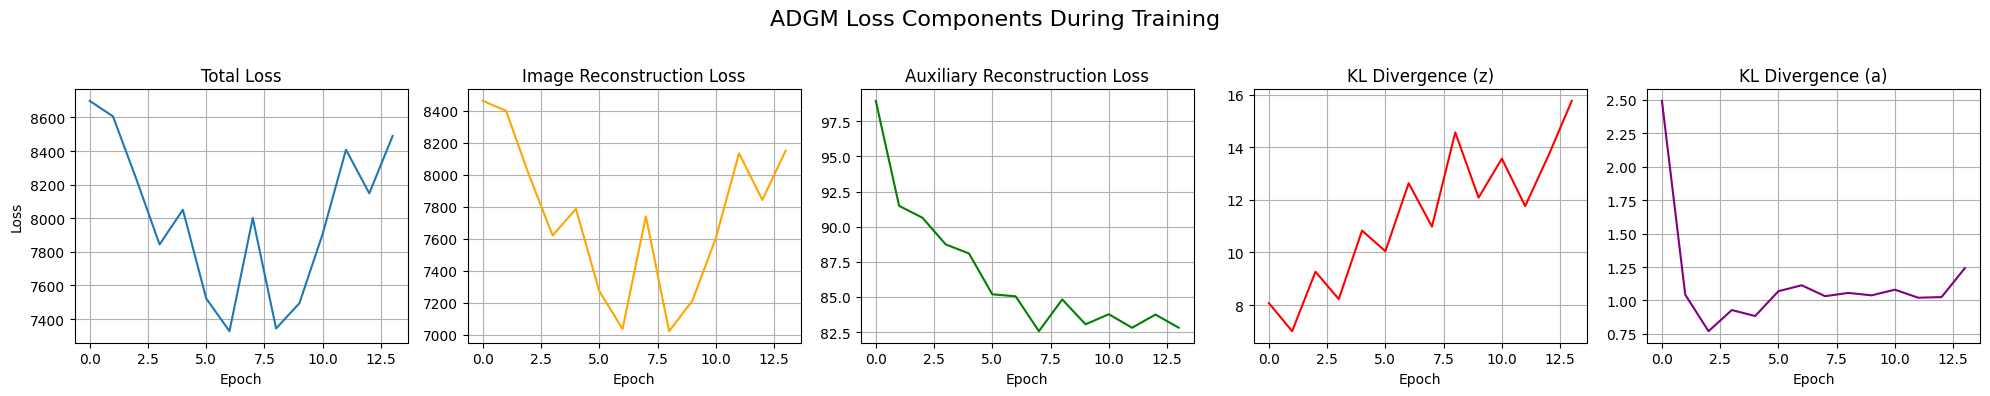

In [19]:
import pandas as pd

# Create a DataFrame from the history object for easier plotting
history_df = pd.DataFrame(history.history)

# Create a horizontal plot with 5 subplots (1 for each loss component + total loss)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('ADGM Loss Components During Training', fontsize=16)

# Plot 1: Total Loss
axes[0].plot(history_df['loss'], label='Total Loss')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Plot 2: Reconstruction Loss (x)
axes[1].plot(history_df['recon_loss_x'], label='Reconstruction Loss (x)', color='orange')
axes[1].set_title('Image Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Plot 3: Reconstruction Loss (a)
axes[2].plot(history_df['recon_loss_a'], label='Reconstruction Loss (a)', color='green')
axes[2].set_title('Auxiliary Reconstruction Loss')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

# Plot 4: KL Divergence (z)
axes[3].plot(history_df['kl_loss_z'], label='KL Loss (z)', color='red')
axes[3].set_title('KL Divergence (z)')
axes[3].set_xlabel('Epoch')
axes[3].grid(True)

# Plot 5: KL Divergence (a)
axes[4].plot(history_df['kl_loss_a'], label='KL Loss (a)', color='purple')
axes[4].set_title('KL Divergence (a)')
axes[4].set_xlabel('Epoch')
axes[4].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for the suptitle
plt.show()

### Latent space plot

In [20]:
# from sklearn.manifold import TSNE
# import seaborn as sns

# # --- 1. Get Latent Representations from the Test Set ---
# print("Generating latent space representations for the test set...")

# # We'll store the latent means (mu_z) and their corresponding labels here
# all_mu_z = []
# all_labels = []

# # Iterate through the entire test dataset
# for images, labels in test_dataset:
#     # Get the outputs from the inference path
#     mu_a, log_var_a = adgm_model.q_a_x_model(images)
#     # We use mu_a as a stable representation for 'a'
#     mu_z, log_var_z = adgm_model.q_z_xa_model([images, mu_a])
    
#     all_mu_z.append(mu_z.numpy())
#     all_labels.append(labels.numpy())

# # Concatenate all batches into single NumPy arrays
# all_mu_z = np.concatenate(all_mu_z, axis=0)
# all_labels = np.concatenate(all_labels, axis=0)

# print(f"Generated {all_mu_z.shape[0]} latent vectors of dimension {all_mu_z.shape[1]}.")


# # --- 2. Apply t-SNE ---
# print("Applying t-SNE to reduce dimensionality to 2D... (this may take a minute)")

# tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
# latent_space_2d = tsne.fit_transform(all_mu_z)

# print("t-SNE finished.")


# # --- 3. Plot the 2D Latent Space ---

# plt.figure(figsize=(12, 10))

# # Dynamically determine the number of classes and create a color palette
# num_classes = len(np.unique(all_labels))
# palette = sns.color_palette("hsv", num_classes)

# # Create the scatter plot
# scatter = sns.scatterplot(
#     x=latent_space_2d[:, 0],
#     y=latent_space_2d[:, 1],
#     hue=all_labels,
#     palette=palette,
#     legend='full',
#     s=10 # Marker size
# )

# plt.title('t-SNE Visualization of the ADGM Latent Space (z)', fontsize=16)
# plt.xlabel('t-SNE Component 1')
# plt.ylabel('t-SNE Component 2')
# plt.legend(title='Digit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

### Labeled latent space

Found 2612 files belonging to 4 classes.
Found 4 classes: ['anaphase', 'metaphase', 'prophase', 'telophase']
Generating latent space representations for the labeled set...
Generated 2612 latent vectors.
Applying t-SNE to reduce dimensionality... (this may take a moment)
t-SNE finished.


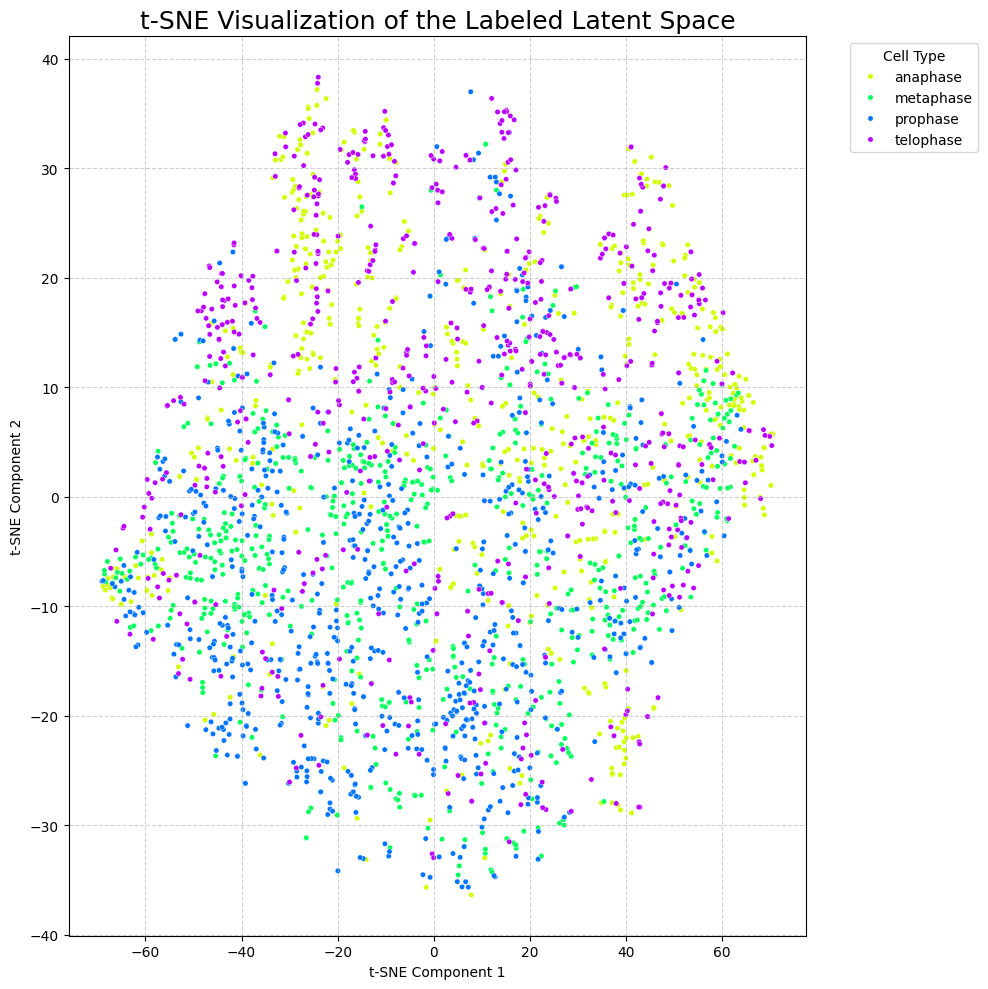

In [21]:
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. Configuration ---
# Ensure these match the paths and settings used for your dataset
IMAGES_LABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/test_v2"
INPUT_SHAPE = (200, 200)
BATCH_SIZE = 32

# --- 2. Load Labeled Dataset and Get Class Names ---
# We need to create a dataset object to get the class names and iterate through the data.
labeled_dataset = tf.keras.utils.image_dataset_from_directory(
    IMAGES_LABELED_PATH,
    labels='inferred',
    image_size=INPUT_SHAPE,
    color_mode='grayscale', # Ensure this matches your model's input
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle for inference
)
class_names = labeled_dataset.class_names
print(f"Found {len(class_names)} classes: {class_names}")

# Normalize the images in the same way as during training
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

labeled_dataset = labeled_dataset.map(preprocess).prefetch(buffer_size=tf.data.AUTOTUNE)

# --- 3. Get Latent Representations from the Labeled Set ---
print("Generating latent space representations for the labeled set...")
all_mu_z = []
all_labels = []

# Iterate through the entire labeled dataset
for images, labels in labeled_dataset:
    # Pass images through the inference path of your trained ADGM model
    mu_a, _ = adgm_model.q_a_x_model(images)
    mu_z, _ = adgm_model.q_z_xa_model([images, mu_a])
    
    all_mu_z.append(mu_z.numpy())
    all_labels.append(labels.numpy())

# Concatenate all batches into single NumPy arrays
all_mu_z = np.concatenate(all_mu_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Generated {all_mu_z.shape[0]} latent vectors.")

# --- 4. Apply t-SNE ---
print("Applying t-SNE to reduce dimensionality... (this may take a moment)")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
latent_space_2d = tsne.fit_transform(all_mu_z)
print("t-SNE finished.")

# --- 5. Plot the 2D Latent Space ---
plt.figure(figsize=(10, 10))

# Use seaborn for a nice color palette and scatter plot
palette = sns.color_palette("hsv", len(class_names))

scatter = sns.scatterplot(
    x=latent_space_2d[:, 0],
    y=latent_space_2d[:, 1],
    hue=all_labels,
    palette=palette,
    legend='full',
    s=15 # Adjust marker size if needed
)

# Create a more readable legend using the actual class names
handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles, class_names, title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('t-SNE Visualization of the Labeled Latent Space', fontsize=18)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Labeled latent space with images

In [22]:
# --- 1. Get Latent Representations AND Images from the Test Set ---
print("Generating latent space representations for the test set...")

all_mu_z = []
all_labels = []
all_images = [] # NEW: Add a list to store the images

# Iterate through the entire test dataset
for images, labels in test_dataset:
    mu_a, _ = adgm_model.q_a_x_model(images)
    mu_z, _ = adgm_model.q_z_xa_model([images, mu_a])
    
    all_mu_z.append(mu_z.numpy())
    all_labels.append(labels.numpy())
    all_images.append(images.numpy()) # NEW: Store the images

# Concatenate all batches into single NumPy arrays
all_mu_z = np.concatenate(all_mu_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_images = np.concatenate(all_images, axis=0) # NEW: Concatenate images too

print(f"Generated {all_mu_z.shape[0]} latent vectors and images.")

Generating latent space representations for the test set...
Generated 1688 latent vectors and images.


2025-08-31 09:38:22.132766: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Applying t-SNE to reduce dimensionality... (this may take a minute)
t-SNE finished.


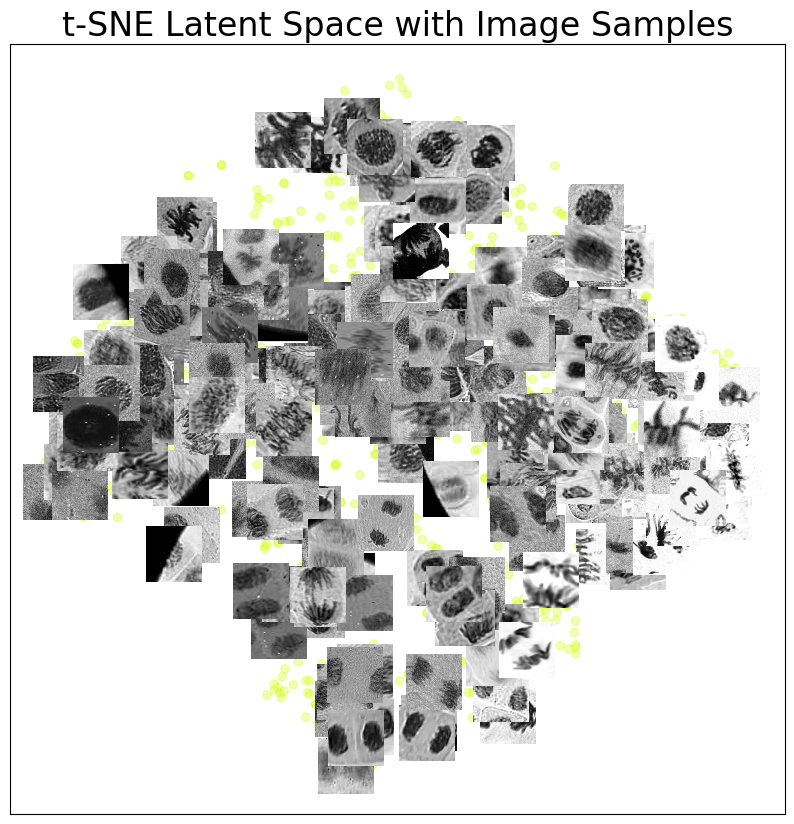

In [23]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# --- 2. Apply t-SNE (This part is unchanged) ---
print("Applying t-SNE to reduce dimensionality... (this may take a minute)")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
latent_space_2d = tsne.fit_transform(all_mu_z)
print("t-SNE finished.")


# --- 3. Plot the 2D Latent Space with Image Thumbnails ---

def plot_latent_space_with_images(latent_2d, images, labels, num_to_plot=200, figsize=10):
    """
    Creates a t-SNE plot with a random subset of image thumbnails overlaid.
    """
    # Create a figure and axes
    fig, ax = plt.subplots(figsize=(figsize, figsize))
    
    # Get class names and colors if available, otherwise generate them
    if 'class_names' in globals():
        names = class_names
    else:
        names = [str(i) for i in np.unique(labels)]
    
    num_classes = len(names)
    palette = sns.color_palette("hsv", num_classes)
    
    # Plot all points as a semi-transparent scatter plot for context
    ax.scatter(latent_2d[:, 0], latent_2d[:, 1], c=[palette[l] for l in labels], alpha=0.3)
    
    # Randomly select a subset of images to display
    indices = np.random.choice(len(images), size=num_to_plot, replace=False)
    
    # Add the image thumbnails
    for i in indices:
        x, y = latent_2d[i]
        img = images[i]
        # OffsetImage creates a container for the image
        # AnnotationBbox places this container at the (x,y) coordinate
        imagebox = OffsetImage(img.squeeze(), cmap='gray', zoom=0.2)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.0)
        ax.add_artist(ab)
        
    ax.set_title('t-SNE Latent Space with Image Samples', fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Call the new plotting function
plot_latent_space_with_images(latent_space_2d, all_images, all_labels)

### Reconstruction plot

In [24]:
# def generate_and_plot_images(model, num_images_to_generate):
#     # Sample random points from the standard normal distribution (our prior p(z)).
#     random_latent_vectors = tf.random.normal(shape=(num_images_to_generate, model.q_z_xa_model.mu_z_layer.units))
    
#     # Use the generative decoder p(x|z) to generate images from these points.
#     generated_images = model.p_x_z_model(random_latent_vectors)
    
#     # Plot the results
#     plt.figure(figsize=(10, 10))
#     for i in range(num_images_to_generate):
#         plt.subplot(5, 5, i + 1)
#         plt.imshow(generated_images[i, :, :, 0], cmap='gray')
#         plt.axis('off')
#     plt.suptitle("Generated Digits from Latent Space", fontsize=16)
#     plt.show()

# # Generate 25 new images
# print("\nGenerating new images from the trained model...")
# generate_and_plot_images(adgm_model, 25)

In [25]:
# Create a dataset object from your LABELED images path to get the class names
labeled_dataset_for_names = tf.keras.utils.image_dataset_from_directory(
    IMAGES_LABELED_PATH,
    labels='inferred',
    image_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE
)
class_names = labeled_dataset_for_names.class_names
print(f"Found class names: {class_names}")

Found 2612 files belonging to 4 classes.
Found class names: ['anaphase', 'metaphase', 'prophase', 'telophase']


Calculating latent space centroids for each class...
Centroids calculated.


/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


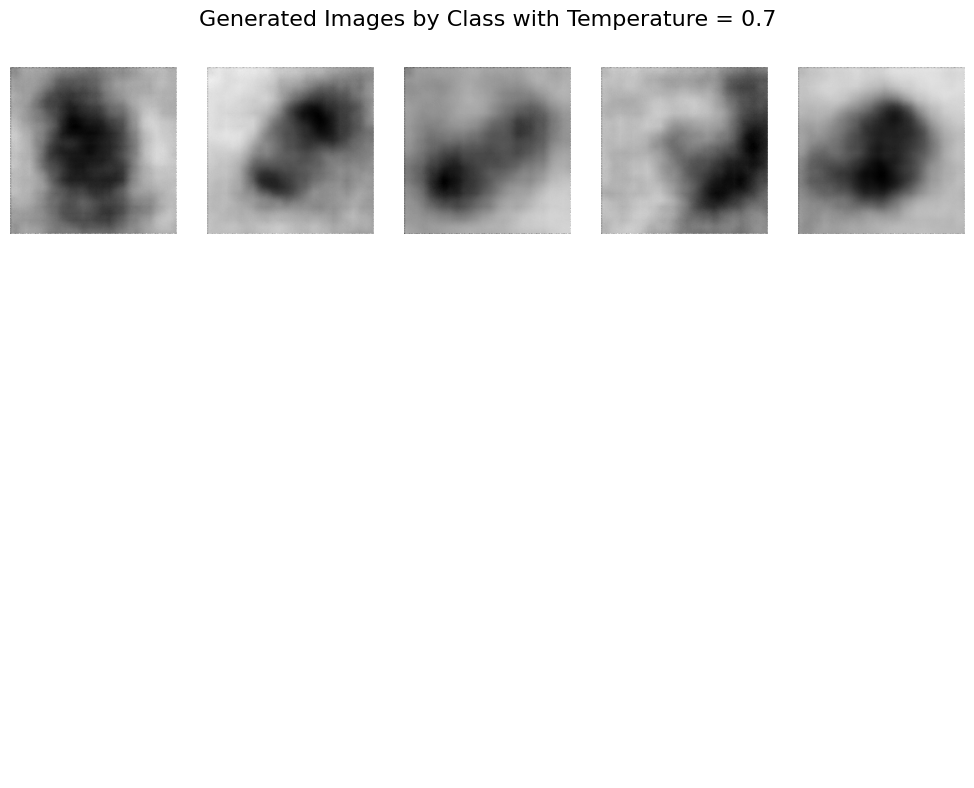

In [26]:
# --- 1. Calculate Latent Space Centroids for Each Class ---
# (This assumes you have run the prerequisite step to get all_mu_z and all_labels
# from your labeled test set).

print("Calculating latent space centroids for each class...")
num_classes = len(class_names) # CHANGED: Use the length of your class_names list
latent_dim = all_mu_z.shape[1]
class_centroids = {}

for i in range(num_classes):
    # This part remains the same
    class_mu_z = all_mu_z[all_labels == i]
    class_centroids[i] = np.mean(class_mu_z, axis=0)

print("Centroids calculated.")


# --- 2. Generate and Plot Images with Temperature Control ---

temperature = 0.7
num_samples_per_class = 5

# Create the plot matrix
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 2 * num_classes)) # Dynamic figsize
fig.suptitle(f'Generated Images by Class with Temperature = {temperature}', fontsize=16)

# CHANGED: Loop using enumerate on class_names
for i, class_name in enumerate(class_names):
    centroid = class_centroids[i].reshape(1, latent_dim)
    
    # CHANGED: Use the actual class name in the y-label
    axes[i, 0].set_ylabel(f'Class "{class_name}"', rotation=0, size='large', labelpad=40)
    
    for j in range(num_samples_per_class):
        epsilon = tf.random.normal(shape=(1, latent_dim))
        z_sample = centroid + temperature * epsilon
        
        generated_image_tensor = adgm_model.p_x_z_model(z_sample)
        # Use the correct image_shape tuple
        generated_image = generated_image_tensor.numpy().reshape(INPUT_SHAPE[0], INPUT_SHAPE[1], -1)
        
        ax = axes[i, j]
        ax.imshow(generated_image.squeeze(), cmap='gray')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()